#MNE Library installation

In [ ]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 34.2 MB/s eta 0:00:00


In [ ]:
import mne
from google.colab import files

# EDF File  

## EDF File Import

In [ ]:
uploaded = files.upload()

Saving aaaaaaac_s001_t000.edf to aaaaaaac_s001_t000.edf


##EDF File information

Loaded file: aaaaaaac_s001_t000.edf
Extracting EDF parameters from aaaaaaac_s001_t000.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 75249  =      0.000 ...   300.996 secs...

Original channels:
['EEG FP1-LE', 'EEG FP2-LE', 'EEG F3-LE', 'EEG F4-LE', 'EEG C3-LE', 'EEG C4-LE', 'EEG A1-LE', 'EEG A2-LE', 'EEG P3-LE', 'EEG P4-LE', 'EEG O1-LE', 'EEG O2-LE', 'EEG F7-LE', 'EEG F8-LE', 'EEG T3-LE', 'EEG T4-LE', 'EEG T5-LE', 'EEG T6-LE', 'EEG FZ-LE', 'EEG CZ-LE', 'EEG PZ-LE', 'EEG OZ-LE', 'EEG PG1-LE', 'EEG PG2-LE', 'EEG EKG-LE', 'EEG SP2-LE', 'EEG SP1-LE', 'EEG RLC-LE', 'EEG LUC-LE', 'EEG 30-LE', 'EEG T1-LE', 'EEG T2-LE', 'PHOTIC PH']

Sampling frequency: 250.0
Using matplotlib as 2D backend.


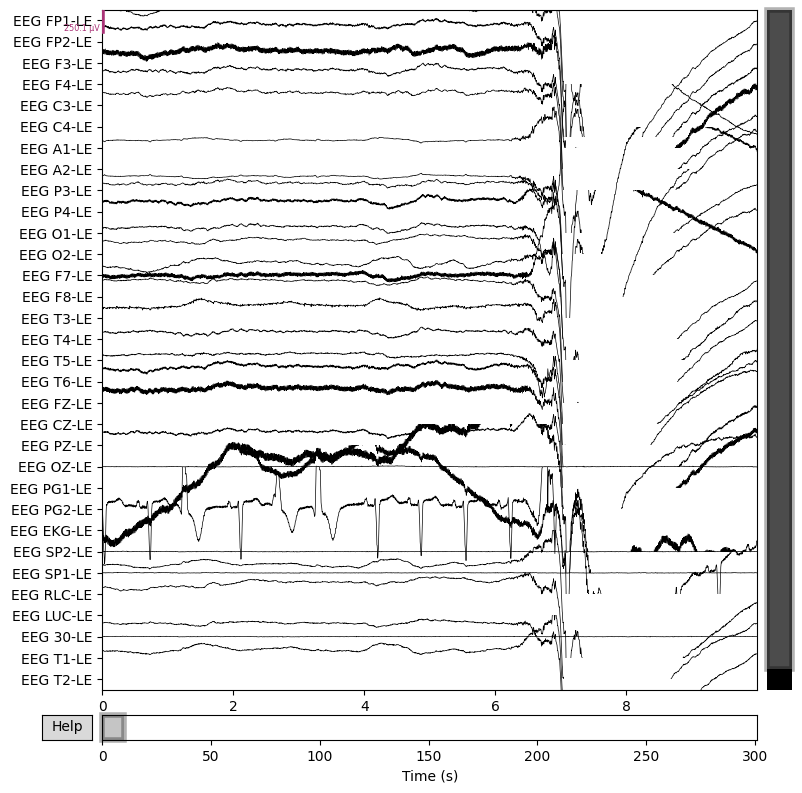

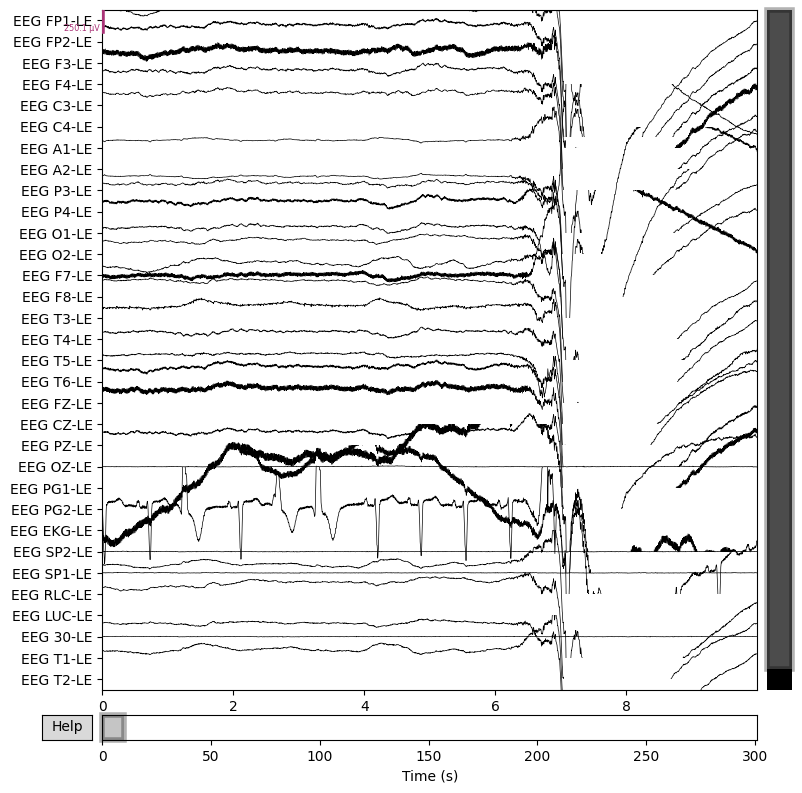

In [ ]:
edf_filename = list(uploaded.keys())[0]

print("Loaded file:", edf_filename)

raw = mne.io.read_raw_edf(edf_filename, preload=True)

print("\nOriginal channels:")
print(raw.ch_names)

print("\nSampling frequency:", raw.info['sfreq'])
# plotting the EEG Channels using Linked Ears montage
raw.plot(
    duration=10,
    n_channels=32,
    title="Original LE Montage",
    scalings="auto"
)

## Defining TCP montage pairs

In [ ]:
tcp_pairs = [
    ('EEG FP1-LE', 'EEG F7-LE'),
    ('EEG F7-LE', 'EEG T3-LE'),
    ('EEG T3-LE', 'EEG T5-LE'),
    ('EEG T5-LE', 'EEG O1-LE'),

    ('EEG FP2-LE', 'EEG F8-LE'),
    ('EEG F8-LE', 'EEG T4-LE'),
    ('EEG T4-LE', 'EEG T6-LE'),
    ('EEG T6-LE', 'EEG O2-LE'),

    ('EEG A1-LE', 'EEG T3-LE'),
    ('EEG T3-LE', 'EEG C3-LE'),
    ('EEG C3-LE', 'EEG CZ-LE'),
    ('EEG CZ-LE', 'EEG C4-LE'),
    ('EEG C4-LE', 'EEG T4-LE'),
    ('EEG T4-LE', 'EEG A2-LE'),

    ('EEG FP1-LE', 'EEG F3-LE'),
    ('EEG F3-LE', 'EEG C3-LE'),
    ('EEG C3-LE', 'EEG P3-LE'),
    ('EEG P3-LE', 'EEG O1-LE'),

    ('EEG FP2-LE', 'EEG F4-LE'),
    ('EEG F4-LE', 'EEG C4-LE'),
    ('EEG C4-LE', 'EEG P4-LE'),
    ('EEG P4-LE', 'EEG O2-LE'),
]

In [ ]:
tcp_raw = mne.set_bipolar_reference(
    raw,
    anode=[p[0] for p in tcp_pairs],
    cathode=[p[1] for p in tcp_pairs],
    ch_name=[
        'FP1-F7','F7-T3','T3-T5','T5-O1',
        'FP2-F8','F8-T4','T4-T6','T6-O2',
        'A1-T3','T3-C3','C3-CZ','CZ-C4','C4-T4','T4-A2',
        'FP1-F3','F3-C3','C3-P3','P3-O1',
        'FP2-F4','F4-C4','C4-P4','P4-O2'
    ],
    drop_refs=False
)

EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=22, n_times=75250
    Range : 0 ... 75249 =      0.000 ...   300.996 secs
Ready.
Added the following bipolar channels:
FP1-F7, F7-T3, T3-T5, T5-O1, FP2-F8, F8-T4, T4-T6, T6-O2, A1-T3, T3-C3, C3-CZ, CZ-C4, C4-T4, T4-A2, FP1-F3, F3-C3, C3-P3, P3-O1, FP2-F4, F4-C4, C4-P4, P4-O2


In [ ]:
tcp_channel_names = [
    'FP1-F7','F7-T3','T3-T5','T5-O1',
    'FP2-F8','F8-T4','T4-T6','T6-O2',
    'A1-T3','T3-C3','C3-CZ','CZ-C4','C4-T4','T4-A2',
    'FP1-F3','F3-C3','C3-P3','P3-O1',
    'FP2-F4','F4-C4','C4-P4','P4-O2'
]

tcp_raw.pick_channels(tcp_channel_names)

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


<RawEDF | aaaaaaac_s001_t000.edf, 22 x 75250 (301.0 s), ~12.7 MiB, data loaded>

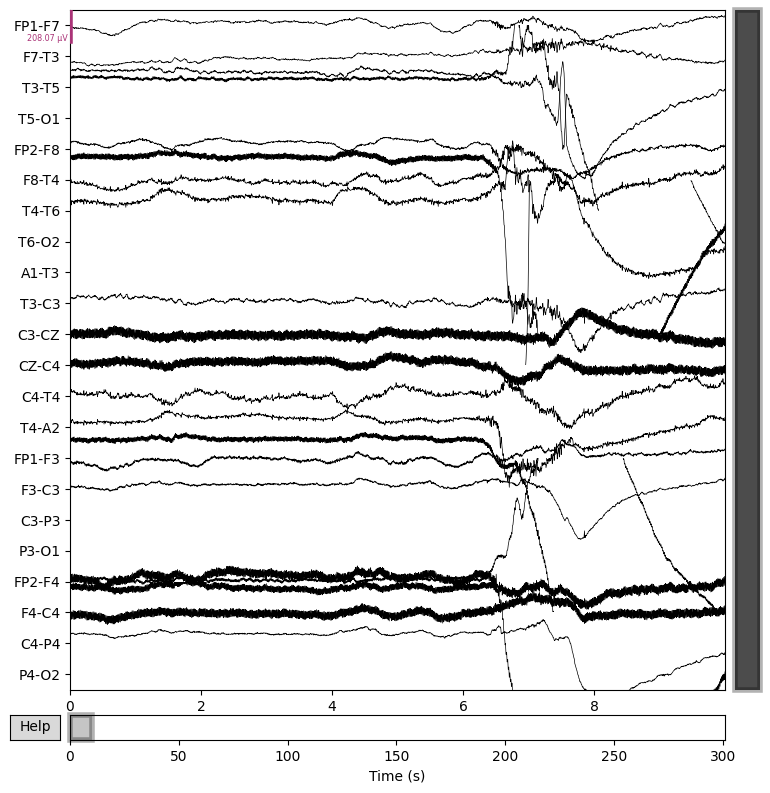

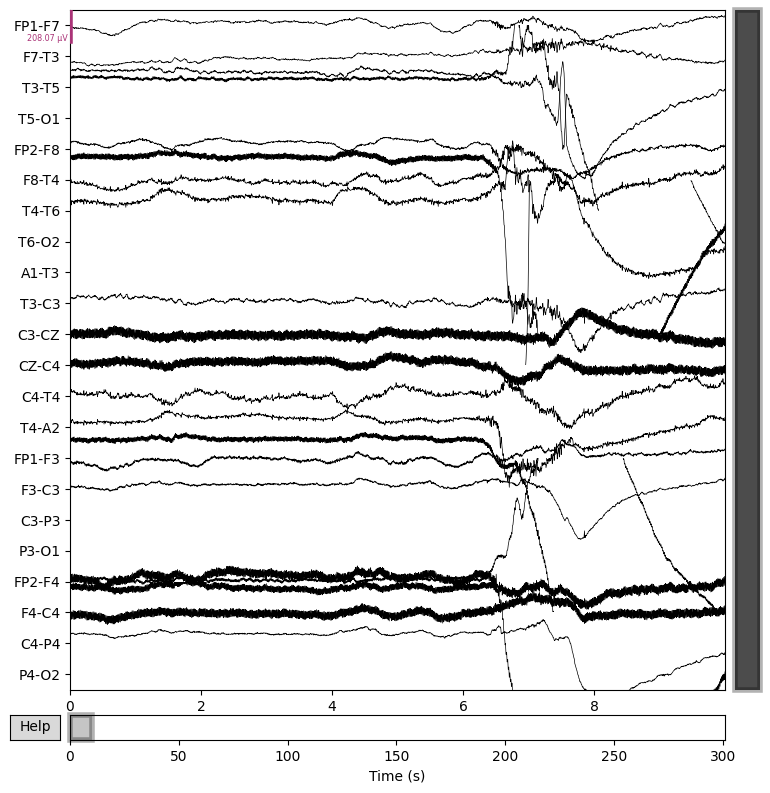

In [ ]:
tcp_raw.plot(
    duration=10,
    n_channels=22,
    title="TCP Montage (Converted from LE)",
    scalings="auto"
)

##Filtering the TCP Signal

In [ ]:
# Bandpass filter: 0.5–40 Hz
tcp_filtered = tcp_raw.copy().filter(l_freq=0.5, h_freq=40)

# Notch filter at 50 Hz (line noise)
tcp_filtered.notch_filter(freqs=50)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1651 samples (6.604 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband e

<RawEDF | aaaaaaac_s001_t000.edf, 22 x 75250 (301.0 s), ~12.7 MiB, data loaded>

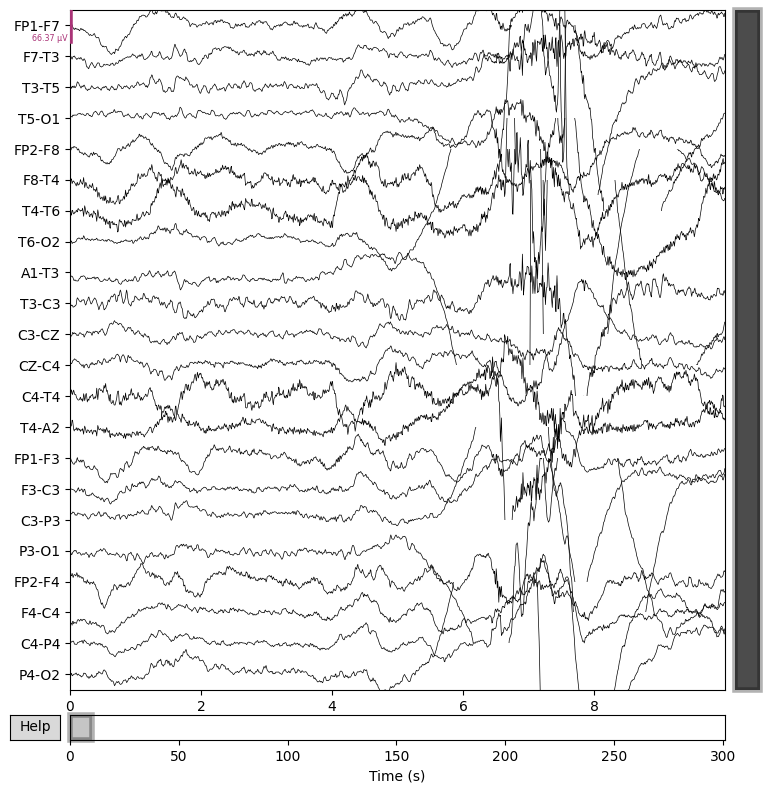

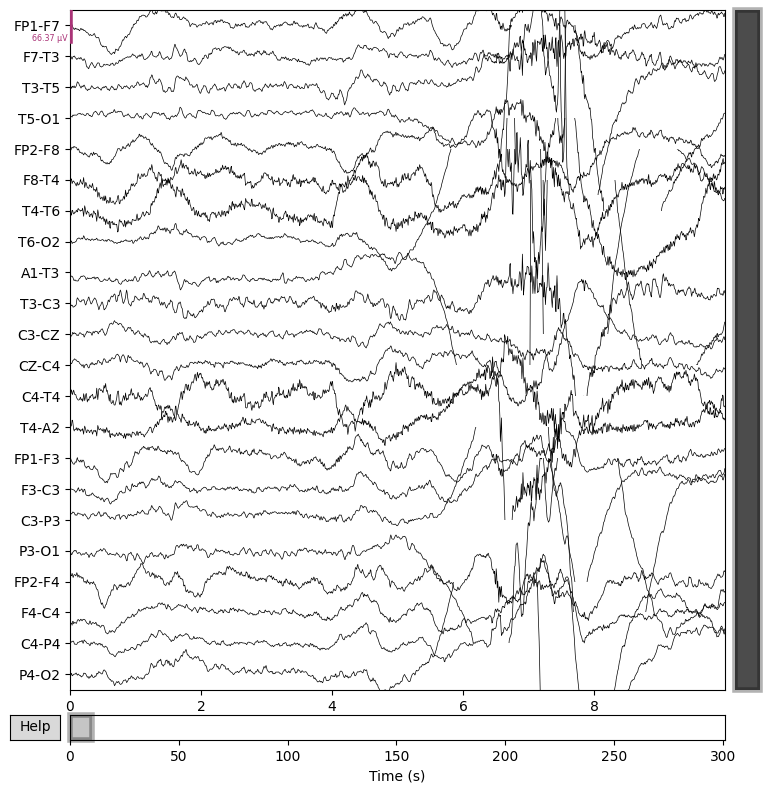

In [ ]:
tcp_filtered.plot(
    duration=10,
    n_channels=22,
    title="TCP Montage (Filtered for Visualization)",
    scalings='auto'
)

##Windowing

In [ ]:
import numpy as np
import mne

# --- 1. Parameters ---
window_sec = 10                # window size in seconds
sfreq = int(tcp_filtered.info['sfreq']) # sampling rate (250 Hz)
window_samples = window_sec * sfreq
overlap = 0.5                   # 50% overlap
step = int(window_samples * (1 - overlap))  # step size between windows

# --- 2. Get data from MNE Raw object ---
# This returns shape: (n_channels, n_times)
eeg_data = tcp_filtered.get_data()
n_channels, n_times = eeg_data.shape
print(f"EEG shape: {n_channels} channels, {n_times} time points")

# --- 3. Segment into overlapping windows ---
windows = []
start = 0
while start + window_samples <= n_times:
    end = start + window_samples
    window = eeg_data[:, start:end]  # shape: (22, 2500)
    windows.append(window)
    start += step  # move start by step size

# Convert list to NumPy array
windows = np.array(windows)  # shape: (num_windows, n_channels, window_samples)
print(f"Windows array shape: {windows.shape}")

EEG shape: 22 channels, 75250 time points
Windows array shape: (59, 22, 2500)


##Binary labeling

In [ ]:
import pandas as pd
import numpy as np

# --- 1. Load CSV, skip metadata lines ---
annotations = pd.read_csv(
    'aaaaaaac_s001_t000.csv_bi',
    comment='#'  # skip lines starting with #
)

# --- 2. Extract seizure events ---
# Only columns needed: start_time, stop_time
seiz_events = annotations[['start_time', 'stop_time']].values

# --- 3. Assign labels to windows ---
labels = []
num_windows = windows.shape[0]

for i in range(num_windows):
    window_start = (i * step) / sfreq       # in seconds
    window_end = window_start + window_sec
    window_label = 0  # default: background

    # Check overlap with any seizure
    for seiz_start, seiz_stop in seiz_events:
        if (window_start < seiz_stop) and (window_end > seiz_start):
            window_label = 1
            break

    labels.append(window_label)

labels = np.array(labels)
print(labels.shape)
print(labels)  # 0 = background, 1 = seizure


(59,)
[0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0]


##Verifying Labels

In [ ]:
for i in range(len(labels)):
    window_start = (i * step) / sfreq
    window_end = window_start + window_sec

    print(f"Window {i:3d}: {window_start:7.2f}s → {window_end:7.2f}s | Label: {labels[i]}")


Window   0:    0.00s →   10.00s | Label: 0
Window   1:    5.00s →   15.00s | Label: 0
Window   2:   10.00s →   20.00s | Label: 0
Window   3:   15.00s →   25.00s | Label: 0
Window   4:   20.00s →   30.00s | Label: 0
Window   5:   25.00s →   35.00s | Label: 0
Window   6:   30.00s →   40.00s | Label: 1
Window   7:   35.00s →   45.00s | Label: 1
Window   8:   40.00s →   50.00s | Label: 1
Window   9:   45.00s →   55.00s | Label: 1
Window  10:   50.00s →   60.00s | Label: 1
Window  11:   55.00s →   65.00s | Label: 1
Window  12:   60.00s →   70.00s | Label: 1
Window  13:   65.00s →   75.00s | Label: 1
Window  14:   70.00s →   80.00s | Label: 1
Window  15:   75.00s →   85.00s | Label: 1
Window  16:   80.00s →   90.00s | Label: 1
Window  17:   85.00s →   95.00s | Label: 1
Window  18:   90.00s →  100.00s | Label: 1
Window  19:   95.00s →  105.00s | Label: 1
Window  20:  100.00s →  110.00s | Label: 1
Window  21:  105.00s →  115.00s | Label: 1
Window  22:  110.00s →  120.00s | Label: 1
Window  23:

##Normalization per window

In [ ]:
#This normalizes each window independently so mean ≈ 0 and std ≈ 1.

import numpy as np

# windows shape: (59, 22, 2500)

windows_normalized = (
    windows - np.mean(windows, axis=(1, 2), keepdims=True)
) / (
    np.std(windows, axis=(1, 2), keepdims=True) + 1e-8
)

windows_normalized.shape
# (59, 22, 2500) for this file


(59, 22, 2500)

## Normalization Verification codes

In [ ]:
# Check first 5 windows
for i in range(5):
    mean = np.mean(windows_normalized[i])
    std = np.std(windows_normalized[i])

    print(f"Window {i}: mean = {mean:.5f}, std = {std:.5f}")

Window 0: mean = 0.00000, std = 0.99994
Window 1: mean = -0.00000, std = 0.99994
Window 2: mean = 0.00000, std = 0.99943
Window 3: mean = 0.00000, std = 0.99944
Window 4: mean = 0.00000, std = 0.99950


In [ ]:
#this snippet verifies Normalization for the entire windows in this file
print("Overall mean:", np.mean(windows_normalized))
print("Overall std:", np.std(windows_normalized))

Overall mean: 1.0948270196611714e-18
Overall std: 0.9996636262355646


## Reshaping Code (add CNN channel dimension)

In [ ]:
import numpy as np

# Add CNN channel dimension
X = windows_normalized[:, np.newaxis, :, :]

# Labels remain the same
y = labels


In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (59, 1, 22, 2500)
y shape: (59,)


In [ ]:
print("X dtype:", X.dtype)
print("y dtype:", y.dtype)


X dtype: float64
y dtype: int64
